# **PCA를 활용한 Eigenface**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

In [ ]:
# (1) Load Data
faces = fetch_olivetti_faces(shuffle=True, random_state=42)

# flatten (400,4096)
X = faces.data

# for visualize (400,64,64)
images = faces.images

print(f"데이터 개수: {X.shape[0]}개")
print(f"이미지 크기: {images.shape[1]}x{images.shape[2]} 픽셀")

데이터 개수: 400개
이미지 크기: 64x64 픽셀


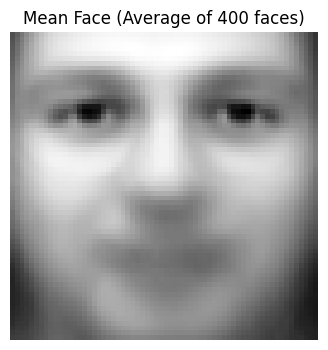

In [ ]:
# (2) 평균 얼굴 구하기 및 시각화

# print(faces.images.shape)
# print(faces.data.shape)
mean_face_vector = np.mean(X, axis=0)
# print(mean_face_vector.shape)

# reshape vector to img (4096x1 -> 64x64)
mean_face_img = mean_face_vector.reshape(64, 64)


plt.figure(figsize=(4, 4))
plt.imshow(mean_face_img, cmap='gray')
plt.title("Mean Face (Average of 400 faces)")
plt.axis('off') # 축 눈금 제거
plt.show()

In [ ]:
# (3)Train PCA (extract eigenfaces)

# 50개의 eigenfaces만을 선택, 원래는 총 400개의 eigenface가 나올 수 있다
n_components = 50

# train PCA
pca = PCA(n_components=n_components, whiten=True, random_state=42)
pca.fit(X)

# Eigenface 추출 및 Reshape (vector -> img)
# (n_components, 4096) -> (n_components, 64, 64)
eigenfaces = pca.components_.reshape((n_components, 64, 64))

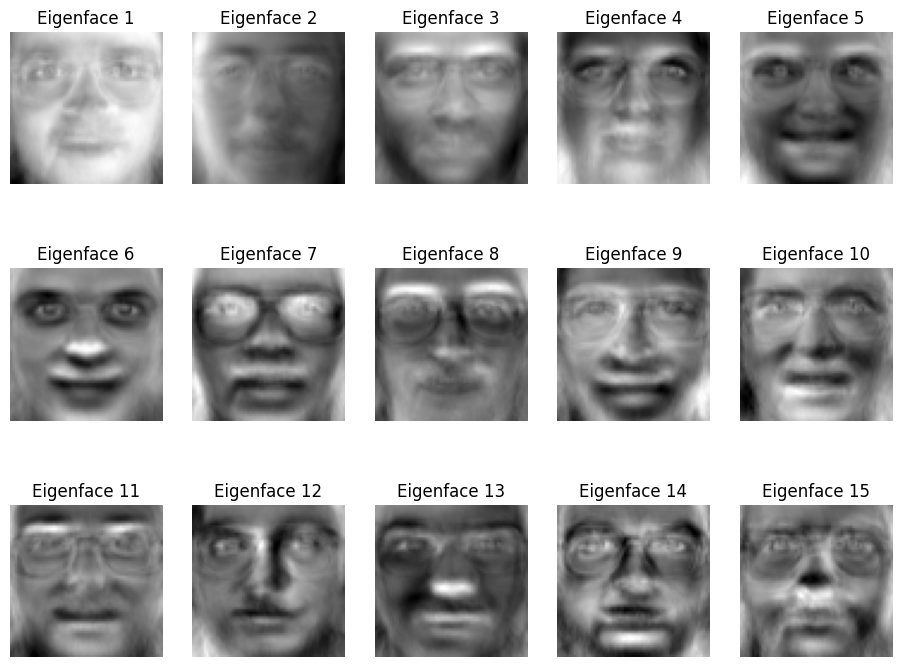

In [ ]:
# (4) visualize eigenfaces
def plot_gallery(images, titles, h, w, n_row=3, n_col=5):
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i], cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.axis('off')
    plt.show()

# eignenfaces.shape = [50, 64, 64]
eigenface_titles = [f"Eigenface {i+1}" for i in range(eigenfaces.shape[0])]

plot_gallery(eigenfaces, eigenface_titles, 64, 64, n_row=3, n_col=5)

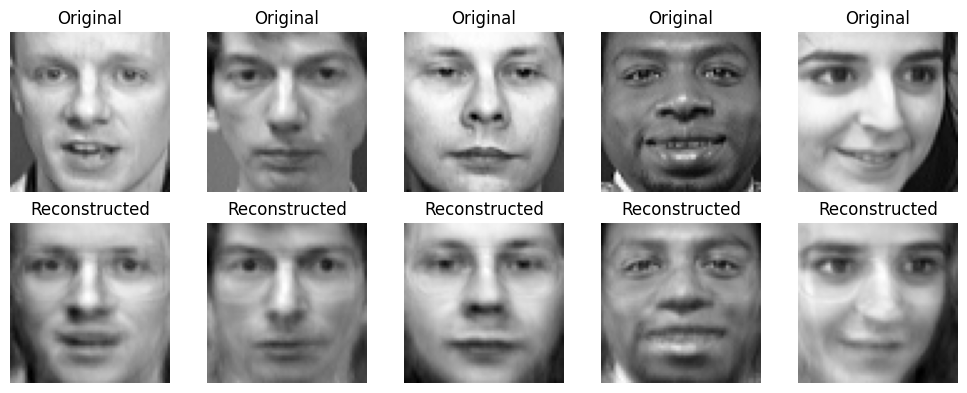

In [ ]:
# (5) 차원 축소 및 재구성
# original(test) -> reduce dimension -> reconstruction
# 4096 -> 60(n_components) -> 4096

# 5명만 테스트로 압축
X_pca = pca.transform(X[:5])

# reconstruction
X_inv = pca.inverse_transform(X_pca)


plt.figure(figsize=(10, 4))
for i in range(5):
    # 원본
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap=plt.cm.gray)
    plt.title("Original")
    plt.axis('off')

    # 복원본
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_inv[i].reshape(64, 64), cmap=plt.cm.gray)
    plt.title("Reconstructed")
    plt.axis('off')
plt.tight_layout()
plt.show()

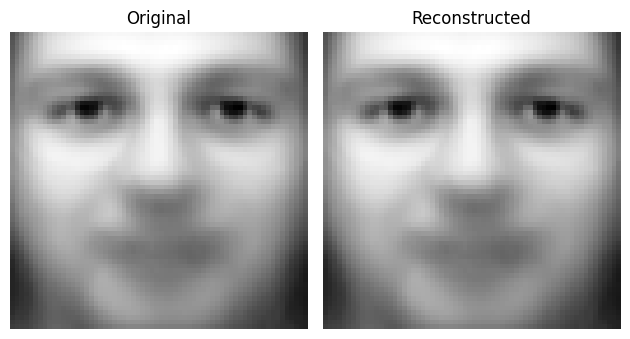

In [ ]:
# mean_face로 test
X_mean_pca = pca.transform(mean_face_vector.reshape(1, -1))

# reconstruction
X_mean_inv = pca.inverse_transform(X_mean_pca)

# 원본
plt.subplot(1, 2, 1)
plt.imshow(mean_face_img, cmap=plt.cm.gray)
plt.title("Original")
plt.axis('off')

# 복원본
plt.subplot(1, 2, 2)
plt.imshow(X_mean_inv.reshape(64, 64), cmap=plt.cm.gray)
plt.title("Reconstructed")
plt.axis('off')
plt.tight_layout()
plt.show()

**LFW Data로 test**

In [ ]:
from sklearn.datasets import fetch_lfw_people
from skimage.transform import resize

(1288, 125, 94)
선택된 인덱스: [377 195 696 916 635]


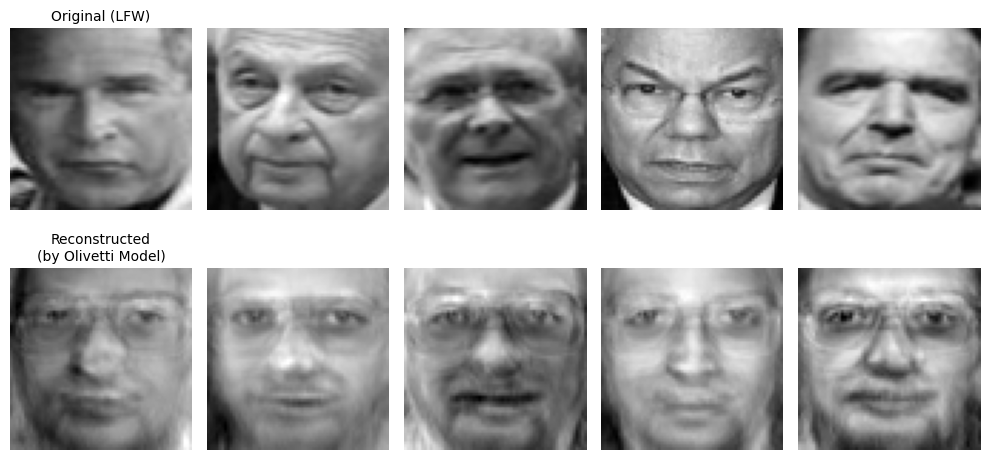

In [ ]:
# 1. LFW 데이터 로드
# min_faces_per_person: 사진이 많은 사람만 추려서 로드 (속도 위해)
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=None)
lfw_images = lfw_people.images

n_samples = len(lfw_images) # 전체 데이터 개수 확인

lfw_images = lfw_people.images

# lfw img의 shape 확인
print(lfw_images.shape) # (1288, 125, 94)

# 5개 숫자를 뽑습니다.
random_indices = np.random.choice(n_samples, 5, replace=False)

print(f"선택된 인덱스: {random_indices}")

# 선택된 인덱스의 이미지만 가져옵니다.
selected_raw_images = lfw_images[random_indices]

# 2. 전처리: 64x64로 강제 변환 (Olivetti와 맞추기 위해)
# 변환된 이미지를 담을 리스트
lfw_64x64 = []

for img in selected_raw_images:
    # skimage.transform.resize를 이용해 64x64
    img_resized = resize(img, (64, 64), anti_aliasing=True, mode='reflect')
    lfw_64x64.append(img_resized)

lfw_64x64 = np.array(lfw_64x64)

# (5, 64, 64) -> (5, 4096)으로 Flatten
lfw_vector = lfw_64x64.reshape(len(lfw_64x64), -1)


# 3. 테스트: Olivetti로 학습된 PCA에 집어넣기
# 'pca' 객체는 Olivetti 데이터로 학습 되어 있다.
lfw_pca = pca.transform(lfw_vector)         # 압축 (Encoding)
lfw_inv = pca.inverse_transform(lfw_pca)    # 복원 (Decoding)


# 4. 결과 비교 시각화
plt.figure(figsize=(10, 5))

for i in range(5):
    # (1) 원본 LFW 사진 (64x64로 줄인 것)
    plt.subplot(2, 5, i + 1)
    plt.imshow(lfw_64x64[i], cmap='gray')
    if i == 0: plt.title("Original (LFW)", fontsize=10)
    plt.axis('off')

    # (2) Olivetti PCA가 억지로 복원한 사진
    plt.subplot(2, 5, i + 6)
    plt.imshow(lfw_inv[i].reshape(64, 64), cmap='gray')
    if i == 0: plt.title("Reconstructed\n(by Olivetti Model)", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()